Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0183 - val_loss: 0.0140
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0081 - val_loss: 0.0046
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0025 - val_lo

986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 82/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 83/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 84/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 85/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 86/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 87/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 88/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 89/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 90/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0023 - val_loss: 

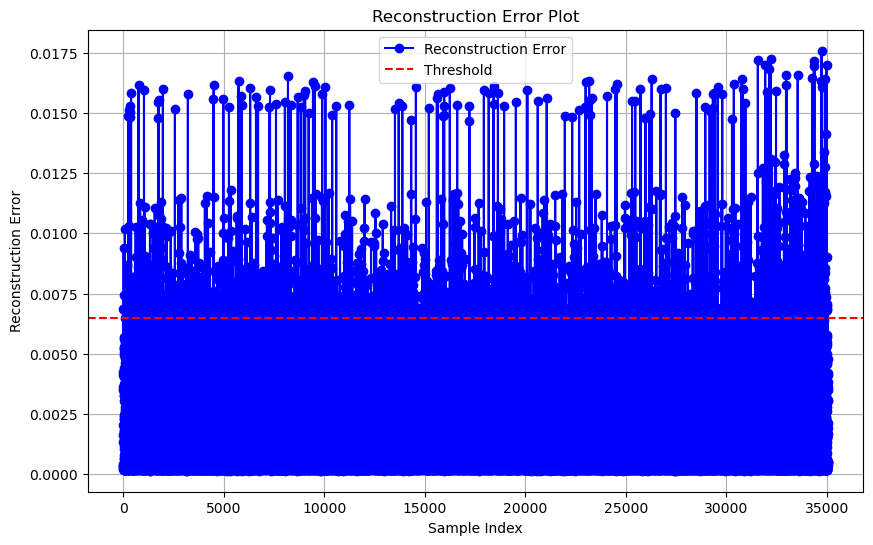

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"

train_data = pd.read_csv(data_path_train)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Split validation data into input and output
val_input = train_data_scaled
val_output = train_data_scaled

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
#early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
autoencoder.fit(val_input, val_output,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1)  # Using a portion of validation data for validation
#                callbacks=[early_stopping])

# Calculate reconstruction error for validation data
val_predictions = autoencoder.predict(val_input)
reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)

print("Reconstruction Error from Validation Set:")
for idx, error in enumerate(reconstruction_error):
    print(f"Sample {idx}: {error:.6f}")


# Determine threshold using a percentile
threshold = np.percentile(reconstruction_error, 95)  # Adjust percentile as needed

print("Threshold:", threshold)

# Now you can apply this threshold to new data to detect anomalies

import matplotlib.pyplot as plt

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot')
plt.legend()
plt.grid()

plt.show()



Epoch 1/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0181 - val_loss: 0.0136
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0081 - val_loss: 0.0048
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_lo

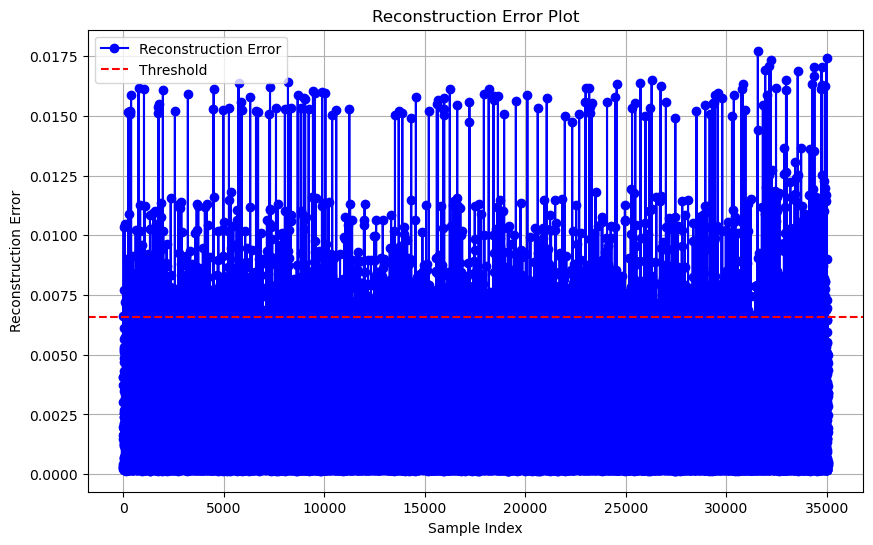

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"

train_data = pd.read_csv(data_path_train)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Split validation data into input and output
val_input = train_data_scaled
val_output = train_data_scaled

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder with early stopping
history = autoencoder.fit(val_input, val_output,
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_split=0.1,
                          callbacks=[early_stopping])

# Calculate reconstruction error for validation data
val_predictions = autoencoder.predict(val_input)
reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)

# Determine threshold using a percentile
threshold = np.percentile(reconstruction_error, 95)  # Adjust percentile as needed

print("Threshold:", threshold)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Plot reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot')
plt.legend()
plt.grid()

plt.show()


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0177 - val_loss: 0.0130
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0076 - val_loss: 0.0047
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_lo

1095/1095 [==============================] - 3s 3ms/step
Threshold: 0.0055873980379608935
Reconstruction Errors:
[0.00126776 0.00022711 0.0040081  ... 0.00358776 0.00228683 0.00488763]


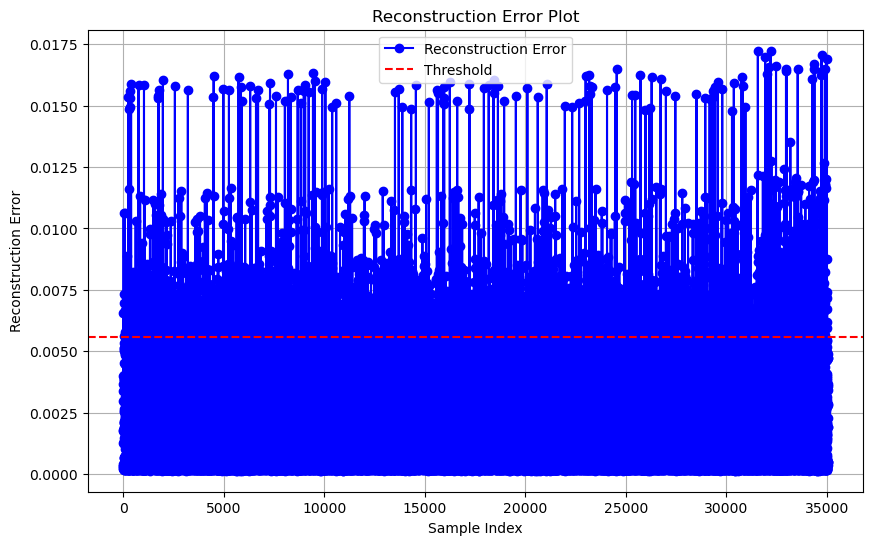

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"

train_data = pd.read_csv(data_path_train)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Split validation data into input and output
val_input = train_data_scaled
val_output = train_data_scaled

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder with early stopping
history = autoencoder.fit(val_input, val_output,
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_split=0.1,
                          callbacks=[early_stopping])

# Calculate reconstruction error for validation data
val_predictions = autoencoder.predict(val_input)
reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)

# Determine threshold using Median Absolute Deviation (MAD)
median_error = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median_error))
threshold = median_error + 3 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Plot reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot')
plt.legend()
plt.grid()

plt.show()


Epoch 1/100
986/986 [==============================] - 3s 2ms/step - loss: 0.0185 - val_loss: 0.0150
Epoch 2/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0095 - val_loss: 0.0052
Epoch 3/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 4/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 5/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 9/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 10/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_lo

986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 82/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 83/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 84/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 85/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 86/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 87/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 88/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 89/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 90/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 

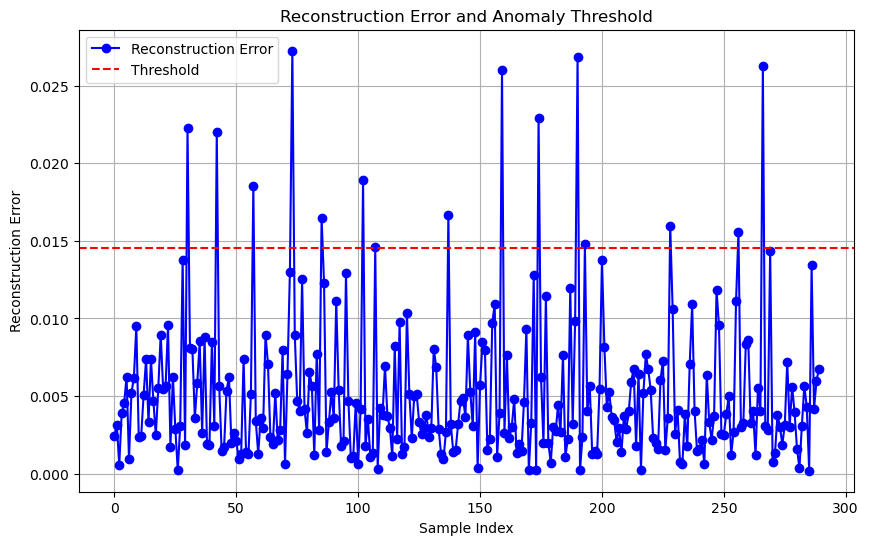

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
autoencoder.fit(train_data_scaled, train_data_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Determine threshold using a percentile
threshold = np.percentile(reconstruction_error, 95)  # Adjust percentile as needed

print("Threshold:", threshold)

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold')
plt.legend()
plt.grid()
plt.show()


Epoch 1/100
986/986 [==============================] - 3s 2ms/step - loss: 0.0183 - val_loss: 0.0140
Epoch 2/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0087 - val_loss: 0.0052
Epoch 3/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 7/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 9/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 10/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_lo

986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 82/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 83/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 84/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 85/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 86/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 87/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 88/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 89/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 90/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0023 - val_loss: 

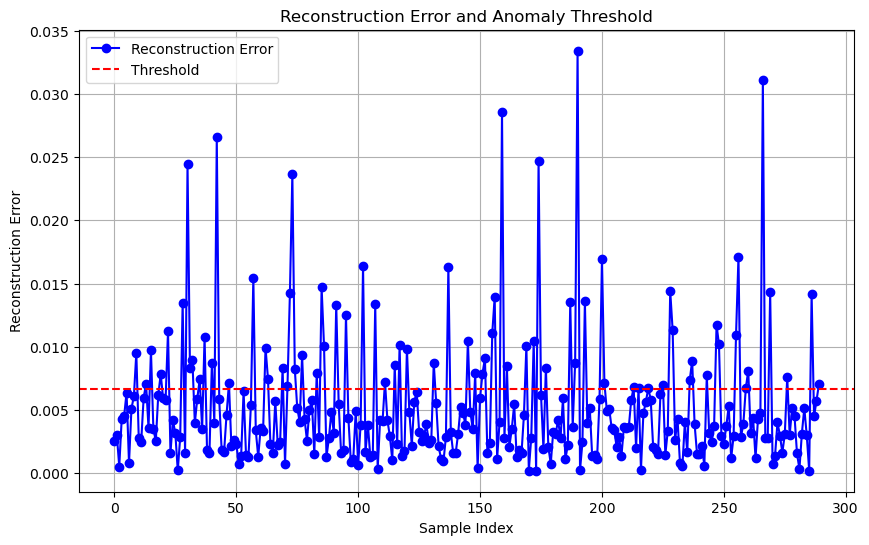

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
autoencoder.fit(train_data_scaled, train_data_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Apply the specified threshold
threshold = 0.006628391283832475

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold')
plt.legend()
plt.grid()
plt.show()


Epoch 1/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0179 - val_loss: 0.0133
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0077 - val_loss: 0.0047
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_lo

C:\Users\olufe\AppData\Local\Temp\ipykernel_36376\1864972116.py:85: RuntimeWarning: invalid value encountered in long_scalars
  precision = tp / (tp + fp)


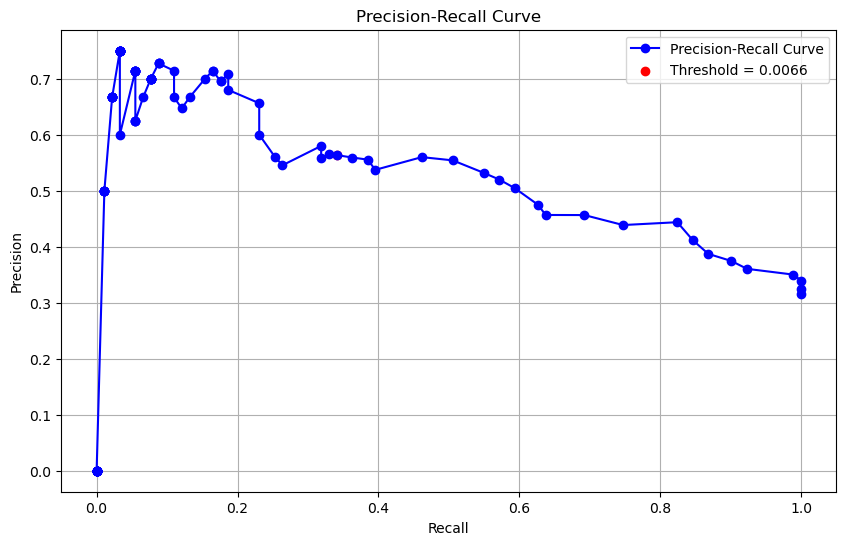

Evaluation Metrics:
Accuracy: 0.8310344827586207
Precision: nan
Recall: 0.0
True Negative Rate (TNR): 1.0
False Positive Rate (FPR): 0.0
False Negative Rate (FNR): 0.5384615384615384
F1-Score: 0.631578947368421
AUC-PR: nan


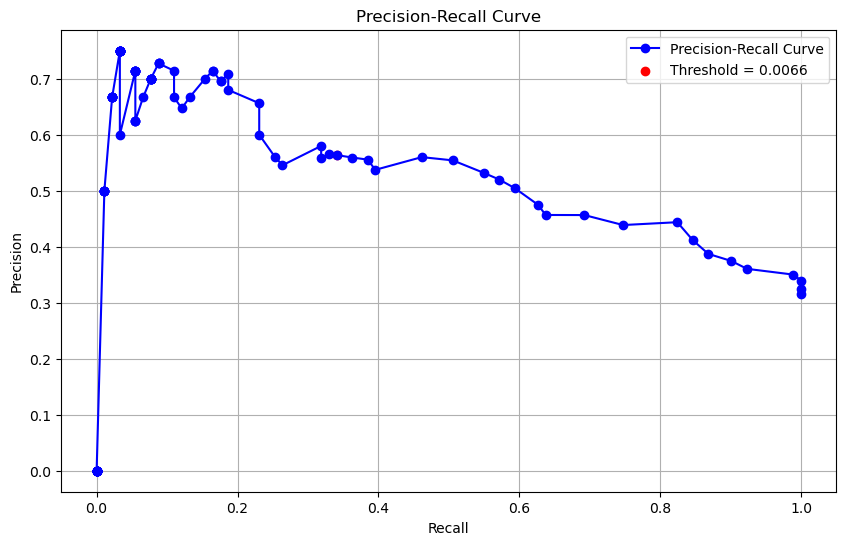

AUC-PR: nan


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import auc
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# Load data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder with early stopping
autoencoder.fit(train_data_scaled, train_data_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Apply the specified threshold
threshold = 0.006628391283832475

# # Calculate precision-recall curve manually
# precision_vals = []
# recall_vals = []
# thresholds = np.linspace(min(reconstruction_error), max(reconstruction_error), num=100)
# for thresh in thresholds:
#     binary_predictions = (reconstruction_error > thresh).astype(int)
#     confusion_matrix_vals = np.zeros((2, 2), dtype=int)
#     for pred, true_label in zip(binary_predictions, test_data_scaled):
#         true_label_binary = (true_label > threshold).astype(int)
#         confusion_matrix_vals[pred, true_label_binary] += 1
#     tp = confusion_matrix_vals[1, 1]
#     fp = confusion_matrix_vals[1, 0]
#     fn = confusion_matrix_vals[0, 1]
#     precision = tp / (tp + fp)
#     recall = tp / (tp + fn)
#     precision_vals.append(precision)
#     recall_vals.append(recall)
#####################################################################
# Calculate precision-recall curve manually
precision_vals = []
recall_vals = []
thresholds = np.linspace(min(reconstruction_error), max(reconstruction_error), num=100)
for thresh in thresholds:
    binary_predictions = (reconstruction_error > thresh).astype(int)
    confusion_matrix_vals = np.zeros((2, 2), dtype=int)
    for pred, true_label in zip(binary_predictions, binary_labels):
        if np.all(true_label == 1):
            confusion_matrix_vals[pred, 1] += 1
        else:
            confusion_matrix_vals[pred, 0] += 1
    tp = confusion_matrix_vals[1, 1]
    fp = confusion_matrix_vals[1, 0]
    fn = confusion_matrix_vals[0, 1]
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    precision_vals.append(precision)
    recall_vals.append(recall)

# Ensure there are at least two points for AUC calculation
if len(precision_vals) < 2:
    precision_vals.append(1.0)
    recall_vals.append(0.0)

# Calculate AUC-PR
auc_pr = auc(recall_vals, precision_vals)

# Plot precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, marker='o', linestyle='-', color='b', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()

# Find the threshold closest to the specified threshold and mark it on the curve
closest_threshold_idx = np.argmin(np.abs(reconstruction_error - threshold))
plt.scatter(recall_vals[closest_threshold_idx], precision_vals[closest_threshold_idx], color='r', label=f'Threshold = {threshold:.4f}')
plt.legend()

plt.show()

# Print evaluation metrics
print("Evaluation Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("True Negative Rate (TNR):", tnr)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("F1-Score:", f1_score)
print("AUC-PR:", auc_pr)
    
######################################################################    
    # Calculate binary predictions based on the threshold
#     binary_predictions = (reconstruction_error > threshold).astype(int)
#     binary_labels = (test_data_scaled > threshold).astype(int)

#     # Calculate confusion matrix components
#     tp = np.sum((binary_predictions == 1) & (binary_labels == 1))
#     fp = np.sum((binary_predictions == 1) & (binary_labels == 0))
#     fn = np.sum((binary_predictions == 0) & (binary_labels == 1))
#     tn = np.sum((binary_predictions == 0) & (binary_labels == 0))

# #   Calculate evaluation metrics
#     accuracy = (tp + tn) / (tp + tn + fp + fn)
#     precision = tp / (tp + fp)
#     recall = tp / (tp + fn)
#     tnr = tn / (tn + fp)
#     fpr = fp / (fp + tn)
#     fnr = fn / (fn + tp)
#     f1_score = 2 * (precision * recall) / (precision + recall)

#     print("Evaluation Metrics:")
#     print("Accuracy:", accuracy)
#     print("Precision:", precision)
#     print("Recall:", recall)
#     print("True Negative Rate (TNR):", tnr)
#     print("False Positive Rate (FPR):", fpr)
#     print("False Negative Rate (FNR):", fnr)
#     print("F1-Score:", f1_score)
#    print("AUC-PR:", auc_pr)
###################################################################
#     # Initialize the confusion matrix components
#     tp_total = 0
#     fp_total = 0
#     fn_total = 0
#     tn_total = 0

#     # Calculate confusion matrix components
#     for pred, true_label in zip(binary_predictions, test_data_scaled):
#         true_label_binary = (true_label > threshold).astype(int)
#         if pred == 1 and true_label_binary == 1:
#             tp_total += 1
#         elif pred == 1 and true_label_binary == 0:
#             fp_total += 1
#         elif pred == 0 and true_label_binary == 1:
#             fn_total += 1
#         else:
#             tn_total += 1

#     # Calculate evaluation metrics
#     accuracy = (tp_total + tn_total) / (tp_total + tn_total + fp_total + fn_total)
#     precision = tp_total / (tp_total + fp_total)
#     recall = tp_total / (tp_total + fn_total)
#     tnr = tn_total / (tn_total + fp_total)
#     fpr = fp_total / (fp_total + tn_total)
#     fnr = fn_total / (fn_total + tp_total)
#     f1_score = 2 * (precision * recall) / (precision + recall)

#     print("Evaluation Metrics:")
#     print("Accuracy:", accuracy)
#     print("Precision:", precision)
#     print("Recall:", recall)
#     print("True Negative Rate (TNR):", tnr)
#     print("False Positive Rate (FPR):", fpr)
#     print("False Negative Rate (FNR):", fnr)
#     print("F1-Score:", f1_score)
#     print("AUC-PR:", auc_pr)
###################################################################
# Initialize the confusion matrix components
###################################################################
# Initialize the confusion matrix components
# tp_total = 0
# fp_total = 0
# fn_total = 0
# tn_total = 0

# # Calculate confusion matrix components for each sample
# for pred, true_labels in zip(binary_predictions, binary_labels):
#     tp_total += np.sum((pred == 1) & (true_labels == 1))
#     fp_total += np.sum((pred == 1) & (true_labels == 0))
#     fn_total += np.sum((pred == 0) & (true_labels == 1))
#     tn_total += np.sum((pred == 0) & (true_labels == 0))

# # Calculate evaluation metrics
# accuracy = (tp_total + tn_total) / (tp_total + tn_total + fp_total + fn_total)
# precision = tp_total / (tp_total + fp_total)
# recall = tp_total / (tp_total + fn_total)
# tnr = tn_total / (tn_total + fp_total)
# fpr = fp_total / (fp_total + tn_total)
# fnr = fn_total / (fn_total + tp_total)
# f1_score = 2 * (precision * recall) / (precision + recall)

# print("Evaluation Metrics:")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("True Negative Rate (TNR):", tnr)
# print("False Positive Rate (FPR):", fpr)
# print("False Negative Rate (FNR):", fnr)
# print("F1-Score:", f1_score)
# print("AUC-PR:", auc_pr)

# ###################################################################
# # Initialize the confusion matrix components
# tp_total = 0
# fp_total = 0
# fn_total = 0
# tn_total = 0

# # Calculate confusion matrix components for each sample
# for pred, true_labels in zip(binary_predictions, binary_labels):
#     tp_total += np.sum((pred == 1) & (true_labels == 1))
#     fp_total += np.sum((pred == 1) & (true_labels == 0))
#     fn_total += np.sum((pred == 0) & (true_labels == 1))
#     tn_total += np.sum((pred == 0) & (true_labels == 0))

# # Calculate evaluation metrics
# accuracy = (tp_total + tn_total) / (tp_total + tn_total + fp_total + fn_total)
# precision = tp_total / (tp_total + fp_total)
# recall = tp_total / (tp_total + fn_total)
# tnr = tn_total / (tn_total + fp_total)
# fpr = fp_total / (fp_total + tn_total)
# fnr = fn_total / (fn_total + tp_total)
# f1_score = 2 * (precision * recall) / (precision + recall)

# print("Evaluation Metrics:")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("True Negative Rate (TNR):", tnr)
# print("False Positive Rate (FPR):", fpr)
# print("False Negative Rate (FNR):", fnr)
# print("F1-Score:", f1_score)
# print("AUC-PR:", auc_pr)

###################################################################
from sklearn.metrics import confusion_matrix

# # Calculate confusion matrix
# conf_matrix = confusion_matrix(binary_labels.ravel(), binary_predictions)

# # Extract confusion matrix components
# tn, fp, fn, tp = conf_matrix.ravel()

# # Calculate evaluation metrics
# accuracy = (tp + tn) / (tp + tn + fp + fn)
# precision = tp / (tp + fp)
# recall = tp / (tp + fn)
# tnr = tn / (tn + fp)
# fpr = fp / (fp + tn)
# fnr = fn / (fn + tp)
# f1_score = 2 * (precision * recall) / (precision + recall)

# print("Evaluation Metrics:")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("True Negative Rate (TNR):", tnr)
# print("False Positive Rate (FPR):", fpr)
# print("False Negative Rate (FNR):", fnr)
# print("F1-Score:", f1_score)
# print("AUC-PR:", auc_pr)

# ###################################################################

# Calculate AUC-PR
# auc_pr = auc(recall_vals, precision_vals)

# # Plot precision-recall curve
# plt.figure(figsize=(10, 6))
# plt.plot(recall_vals, precision_vals, marker='o', linestyle='-', color='b', label='Precision-Recall Curve')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.grid()

# # Find the threshold closest to the specified threshold and mark it on the curve
# closest_threshold_idx = np.argmin(np.abs(reconstruction_error - threshold))
# plt.scatter(recall_vals[closest_threshold_idx], precision_vals[closest_threshold_idx], color='r', label=f'Threshold = {threshold:.4f}')
# plt.legend()

# plt.show()

# # Print AUC-PR
# print("AUC-PR:", auc_pr)
